In [17]:
# Install PyTorch and Torchvision

!pip install torch torchvision pandas scikit-learn matplotlib pillow

In [18]:
# Import required libraries

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

In [20]:
# Use GPU if available, otherwise use CPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

# Load the butterfly dataset CSV
df = pd.read_csv("Training_set.csv")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset columns:")
print(df.columns)

Device: cpu

First 5 rows:
      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART

Dataset columns:
Index(['filename', 'label'], dtype='object')


In [21]:
# Select the 5 species having the most images

classes = df["label"].value_counts().head(5).index

# Keep only these 5 species
df = df[df["label"].isin(classes)]

# Take a maximum of 100 images from each species
df = df.groupby("label").head(100)

print("Number of images per class:")
print(df["label"].value_counts())

print("\nTotal images:", len(df))

Number of images per class:
label
ATALA             100
MOURNING CLOAK    100
SLEEPY ORANGE     100
BROWN SIPROETA     99
CRECENT            97
Name: count, dtype: int64

Total images: 496


In [22]:
# Split the dataset into training and testing sets 70% for training and 30% for testing

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)
# Sort class names and create numerical labels
classes = sorted(df["label"].unique())

class_to_idx = {
    name: i for i, name in enumerate(classes)
}

print("Classes:", classes)
print("Training images:", len(train_df))
print("Testing images:", len(test_df))

print("Number of classes:", len(classes))

Classes: ['ATALA', 'BROWN SIPROETA', 'CRECENT', 'MOURNING CLOAK', 'SLEEPY ORANGE']
Training images: 347
Testing images: 149
Number of classes: 5


In [23]:
# Preprocess every image before giving it to the CNN
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

print("Image preprocessing ready!")

Image preprocessing ready!


In [24]:
# Custom Dataset class for loading butterfly images

class ButterflyDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        image_path = os.path.join(
            "train",
            row["filename"]
        )

        image = Image.open(image_path).convert("RGB")
        image = transform(image)
        label = class_to_idx[row["label"]]

        return image, label

In [25]:
# Create training dataset
train_dataset = ButterflyDataset(train_df)
# Create testing dataset
test_dataset = ButterflyDataset(test_df)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 22
Testing batches: 10


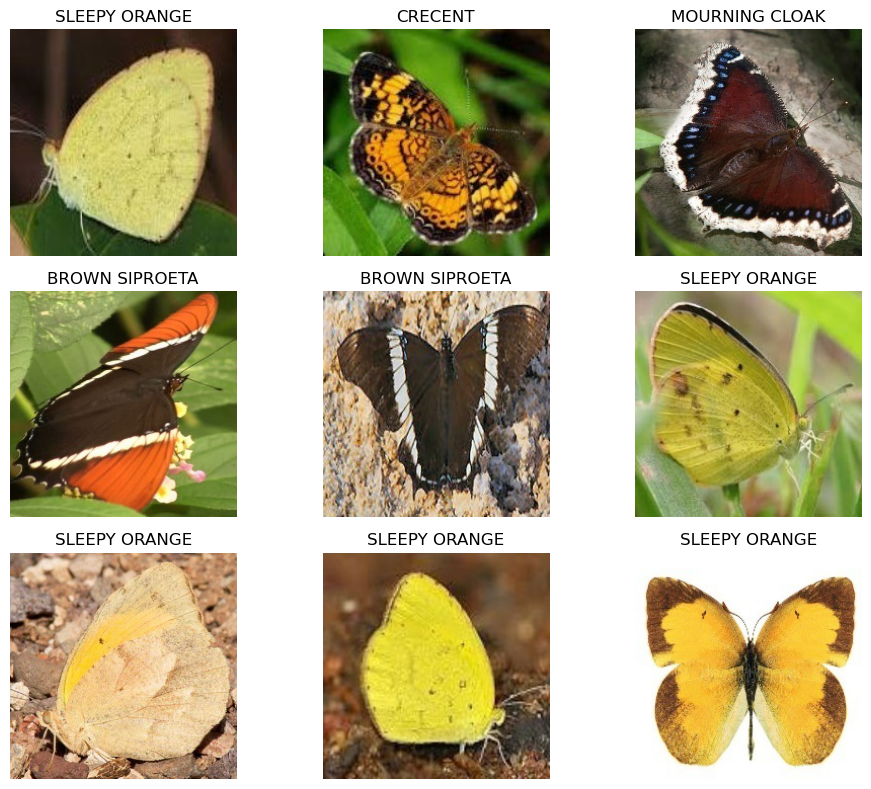

In [26]:
# Display some sample butterfly images

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 8))
for i in range(9):

    plt.subplot(3, 3, i + 1)
    image = images[i].permute(1, 2, 0)

    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ) + torch.tensor(
        [0.485, 0.456, 0.406]
    )
    image = torch.clamp(image, 0, 1)

    plt.imshow(image)
    plt.title(classes[labels[i].item()])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Function to create a pretrained model
# and replace its original classifier

def get_model(name):
    # DenseNet121
    if name == "DenseNet121":

        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        # Replace ImageNet classifier
        model.classifier = nn.Linear(
            model.classifier.in_features,
            len(classes)
        )

        classifier = model.classifier
    # VGG16
    elif name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            len(classes)
        )
        classifier = model.classifier
        
    # ResNet50
    elif name == "ResNet50":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        # Replace final fully connected layer
        model.fc = nn.Linear(
            model.fc.in_features,
            len(classes)
        )

        classifier = model.fc

    # ResNet101
    elif name == "ResNet101":

        model = models.resnet101(
            weights=models.ResNet101_Weights.DEFAULT
        )
        # Replace final fully connected layer
        model.fc = nn.Linear(
            model.fc.in_features,
            len(classes)
        )
        classifier = model.fc

    # Freeze pretrained layers
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Train only the new classifier

    for parameter in classifier.parameters():
        parameter.requires_grad = True
    model = model.to(device)

    return model

In [28]:
# Models that will be compared

model_names = [
    "DenseNet121",
    "VGG16",
    "ResNet50",
    "ResNet101"
]
print("Models to compare:")
for name in model_names:
    print("-", name)

Models to compare:
- DenseNet121
- VGG16
- ResNet50
- ResNet101


In [29]:
# Dictionary to store final test accuracy
results = {}


# Train each pretrained model
for name in model_names:
    print("Training:", name)

    model = get_model(name)
    loss_function = nn.CrossEntropyLoss()

    # Adam optimizer
    optimizer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=0.001
    )

    for epoch in range(3):
        model.train()
        correct = 0
        total = 0
        running_loss = 0

        # Process training batches
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(
                outputs,
                labels
            )
            loss.backward()
            optimizer.step()
            predictions = outputs.argmax(1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            running_loss += loss.item()
        train_accuracy = correct / total
        average_loss = (
            running_loss / len(train_loader)
        )
        print(
            "Epoch",
            epoch + 1,
            "| Loss:",
            round(average_loss, 4),
            "| Accuracy:",
            round(train_accuracy * 100, 2),
            "%"
        )
    # Test the model
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(1)
            correct += (
                predictions == labels
            ).sum().item()
            total += labels.size(0)
    # Calculate test accuracy
    test_accuracy = correct / total

    # Save result
    results[name] = test_accuracy
    print(
        "\n",
        name,
        "Test Accuracy:",
        round(test_accuracy * 100, 2),
        "%"
    )

Training: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Akshada/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:16<00:00, 2.01MB/s]


Epoch 1 | Loss: 1.3173 | Accuracy: 47.55 %
Epoch 2 | Loss: 0.6787 | Accuracy: 91.64 %
Epoch 3 | Loss: 0.4294 | Accuracy: 95.68 %

 DenseNet121 Test Accuracy: 91.95 %
Training: VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Akshada/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [08:35<00:00, 1.07MB/s]   


Epoch 1 | Loss: 1.1668 | Accuracy: 74.64 %
Epoch 2 | Loss: 0.5393 | Accuracy: 95.39 %
Epoch 3 | Loss: 1.1783 | Accuracy: 95.97 %

 VGG16 Test Accuracy: 90.6 %
Training: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Akshada/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:20<00:00, 4.91MB/s]


Epoch 1 | Loss: 1.2949 | Accuracy: 73.78 %
Epoch 2 | Loss: 0.7668 | Accuracy: 96.54 %
Epoch 3 | Loss: 0.516 | Accuracy: 97.69 %

 ResNet50 Test Accuracy: 95.97 %
Training: ResNet101
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\Akshada/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:34<00:00, 5.25MB/s] 


Epoch 1 | Loss: 1.2147 | Accuracy: 64.55 %
Epoch 2 | Loss: 0.6368 | Accuracy: 92.22 %
Epoch 3 | Loss: 0.3723 | Accuracy: 97.98 %

 ResNet101 Test Accuracy: 95.97 %


In [43]:
# Display the accuracy of all four models

print("FINAL MODEL COMPARISON")
for name, accuracy in results.items():

    print(
        f"{name:<15} : {accuracy * 100:.2f}%"
    )

FINAL MODEL COMPARISON
DenseNet121     : 91.95%
VGG16           : 90.60%
ResNet50        : 95.97%
ResNet101       : 95.97%


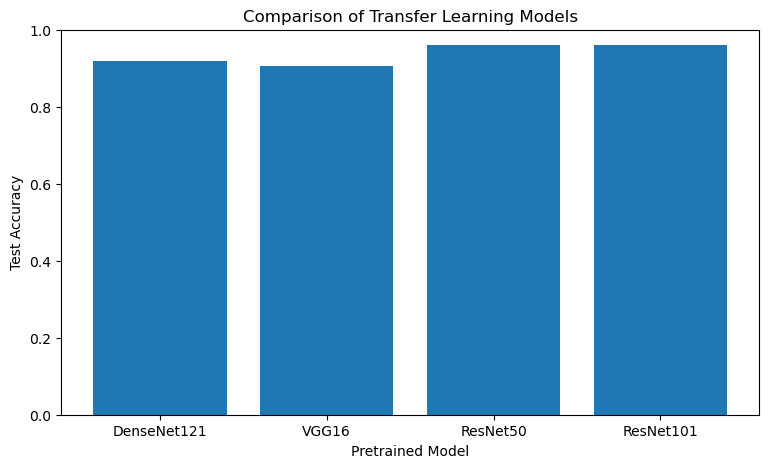

In [44]:
# Create a bar graph comparing all models

plt.figure(figsize=(9, 5))

plt.bar(
    results.keys(),
    results.values()
)
plt.xlabel("Pretrained Model")
plt.ylabel("Test Accuracy")
plt.title(
    "Comparison of Transfer Learning Models"
)
# Display accuracy from 0 to 100%
plt.ylim(0, 1)

plt.show()

In [45]:
# Display results in percentage format

print("Model Accuracy Comparison")
for name, accuracy in results.items():

    print(
        name,
        "->",
        f"{accuracy * 100:.2f}%"
    )

Model Accuracy Comparison
DenseNet121 -> 91.95%
VGG16 -> 90.60%
ResNet50 -> 95.97%
ResNet101 -> 95.97%
